# IMPLEMENTASI PREDIKSI UANG KERTAS (DEPLOYMENT)
Kode ini digunakan untuk menebak gambar uang baru (Unseen Data) 
menggunakan model yang sudah dilatih sebelumnya.

In [9]:
import os
import cv2
import numpy as np
import joblib
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision.models import mobilenet_v2
from skimage.feature import graycomatrix, graycoprops

import warnings
warnings.filterwarnings('ignore')

# ==========================================
# KONFIGURASI PREDIKSI
# ==========================================
# Pilih model yang ingin digunakan: "knn", "rf", atau "cnn"
MODEL_TYPE = "cnn"  

# Jika menggunakan ML Klasik (KNN/RF), tentukan fitur yang dipakai saat training
# Pilihan: "rgb", "hsv", "rgb_glcm", atau "hsv_glcm"
FEATURE_SCENARIO = "hsv_glcm"  

# Path gambar yang ingin ditebak
IMAGE_PATH = "tester50k.png" 

# Daftar Kelas (Harus urut abjad sesuai saat training)
CLASS_NAMES = ['10k', '100k', '20k', '2k', '50k', '5k']

# Resolusi Standar
TARGET_WIDTH_ML, TARGET_HEIGHT_ML = 256, 256
TARGET_WIDTH_CNN, TARGET_HEIGHT_CNN = 224, 224

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Definisi Arsitektur CNN (Jika menggunakan CNN)

In [2]:
class CustomMobileNetV2(nn.Module):
    def __init__(self, num_classes):
        super(CustomMobileNetV2, self).__init__()
        mobilenet = mobilenet_v2()
        self.features = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Sequential(
            nn.Dropout(0.5), nn.Linear(1280, 128), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(128, num_classes)
        )
    def forward(self, x):
        return self.classifier(torch.flatten(self.pool(self.features(x)), 1))

# 2. Fungsi Preprocessing Uang Kertas

In [3]:
def mask_hsv_rupiah(image_bgr, gray_threshold=25, min_area_ratio=0.01, kernel_size=7):
    """ Memisahkan uang kertas dari background menggunakan Otsu Thresholding """
    work_img = image_bgr.copy()
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)
    _, mask = cv2.threshold(gray, gray_threshold, 255, cv2.THRESH_BINARY)
    
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    h, w = mask.shape
    flood = mask.copy()
    flood_mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(flood, flood_mask, (0, 0), 255)
    mask = mask | cv2.bitwise_not(flood)
    
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    refined = np.zeros_like(mask)
    if num_labels > 1:
        largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        if stats[largest_idx, cv2.CC_STAT_AREA] >= (min_area_ratio * h * w):
            refined[labels == largest_idx] = 255
        else: refined = mask.copy()
    else: refined = mask.copy()
    
    return cv2.bitwise_and(work_img, work_img, mask=refined), refined

def crop_and_resize(image_bgr, mask, target_width, target_height, pad_ratio=0.05):
    """ Memotong sesuai objek uang dan meresize secara proporsional """
    coords = cv2.findNonZero(mask)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        pad = int(max(w, h) * pad_ratio)
        h_img, w_img = image_bgr.shape[:2]
        image_bgr = image_bgr[max(y-pad, 0):min(y+h+pad, h_img), max(x-pad, 0):min(x+w+pad, w_img)]
        
    h, w = image_bgr.shape[:2]
    scale = min(target_width / w, target_height / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    resized = cv2.resize(image_bgr, (new_w, new_h), interpolation=cv2.INTER_AREA)
    
    output = np.zeros((target_height, target_width, 3), dtype=np.uint8)
    y_off, x_off = (target_height - new_h) // 2, (target_width - new_w) // 2
    output[y_off:y_off+new_h, x_off:x_off+new_w] = resized
    return output

# 3. Fungsi Ekstraksi Fitur (Khusus ML)

In [4]:
def extract_hsv(image_bgr, grid_size=(2, 2), bins=8):
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    h, w = hsv.shape[:2]
    gh, gw = grid_size
    features = []
    for i in range(gh):
        for j in range(gw):
            cell = hsv[int(i*h/gh):int((i+1)*h/gh), int(j*w/gw):int((j+1)*w/gw)]
            features.extend(cv2.normalize(cv2.calcHist([cell], [0], None, [bins], [0, 180]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [1], None, [bins], [0, 256]), None).flatten())
            features.extend(cv2.normalize(cv2.calcHist([cell], [2], None, [bins], [0, 256]), None).flatten())
    return features

def extract_glcm(image_bgr, levels=32):
    gray = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY)
    gray_q = np.clip(np.floor(gray.astype(np.float32) * levels / 256.0).astype(np.uint8), 0, levels - 1)
    glcm = graycomatrix(gray_q, distances=[1,2,3], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=levels, symmetric=True, normed=True)
    features = []
    for prop in ["contrast", "homogeneity", "energy", "correlation"]:
        features.extend(graycoprops(glcm, prop).flatten())
    return features

# 4. Main Predict Function

In [7]:
def predict_rupiah(image_path, model_type=MODEL_TYPE):
    # ==================================================
    # 1. Baca Gambar
    # ==================================================
    image = cv2.imread(image_path)
    if image is None:
        print(f"❌ Gagal membaca gambar dari {image_path}!")
        return

    # ==================================================
    # 2. Preprocessing Dasar
    # ==================================================
    segmented, mask = mask_hsv_rupiah(image)

    # ==================================================
    # 3. Alur Prediksi (Cabang ML Klasik vs CNN)
    # ==================================================
    if model_type in ["knn", "rf"]:
        # Load Model ML
        model_path = f"models/{model_type}/{FEATURE_SCENARIO}_model.pkl"
        if not os.path.exists(model_path):
            print(f"❌ Model tidak ditemukan di {model_path}")
            return
        model = joblib.load(model_path)
        
        # Preproses ML
        processed = crop_and_resize(segmented, mask, TARGET_WIDTH_ML, TARGET_HEIGHT_ML)
        
        # Ekstrak Fitur Dinamis berdasarkan Skenario
        features = []
        if "hsv" in FEATURE_SCENARIO: features.extend(extract_hsv(processed))
        # Jika ada RGB, tambahkan fungsi extract_rgb di sini
        if "glcm" in FEATURE_SCENARIO: features.extend(extract_glcm(processed))
        
        features_array = np.array(features).reshape(1, -1)
        
        # Scale khusus KNN
        if model_type == "knn":
            scaler = joblib.load(f"models/knn/{FEATURE_SCENARIO}_scaler.pkl")
            features_array = scaler.transform(features_array)
            
        # Dapatkan Probabilitas
        probabilities = model.predict_proba(features_array)[0]
        
    elif model_type == "cnn":
        # Load Model CNN
        model_path = 'models/MobileNetV2CrossVal.pth'
        if not os.path.exists(model_path):
            print(f"❌ Model tidak ditemukan di {model_path}")
            return
        model = CustomMobileNetV2(len(CLASS_NAMES)).to(device)
        model.load_state_dict(torch.load(model_path, map_location=device))
        model.eval()
        
        # Preproses CNN (Rentang -1 hingga 1)
        processed = crop_and_resize(segmented, mask, TARGET_WIDTH_CNN, TARGET_HEIGHT_CNN)
        normed = (cv2.cvtColor(processed, cv2.COLOR_BGR2RGB).astype(np.float32) / 127.5) - 1.0
        
        input_tensor = torch.tensor(np.transpose(normed, (2, 0, 1)), dtype=torch.float32).unsqueeze(0).to(device)
        
        with torch.no_grad():
            outputs = model(input_tensor)
            probabilities = torch.nn.functional.softmax(outputs, dim=1).cpu().numpy()[0]

    else:
        print("Model Type tidak valid!")
        return

    # ==================================================
    # 4. Tentukan Label & Confidence
    # ==================================================
    best_idx = np.argmax(probabilities)
    best_confidence = probabilities[best_idx] * 100
    predicted_label = CLASS_NAMES[best_idx]

    # ==================================================
    # 5. Visualisasi
    # ==================================================
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    
    # Original Image
    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Citra Asli")
    axes[0].axis("off")

    # Preprocessed Image
    axes[1].imshow(cv2.cvtColor(processed, cv2.COLOR_BGR2RGB))
    axes[1].set_title("Hasil Preprocessing (Cropped)")
    axes[1].axis("off")

    plt.suptitle(f"Prediksi: {predicted_label} | Keyakinan: {best_confidence:.2f}%", 
                 fontsize=14, fontweight='bold', color='darkgreen')
    plt.tight_layout()
    plt.show()

    # ==================================================
    # 6. Cetak Rincian Hasil
    # ==================================================
    print("=" * 60)
    print(f" HASIL PREDIKSI (MENGGUNAKAN {model_type.upper()})")
    print("=" * 60)
    print(f" Prediksi Akhir : Nominal {predicted_label}")
    print(f" Nilai Keyakinan: {best_confidence:.2f}%")
    print("\n Rincian Confidence Score Tiap Kelas:")
    
    for cls, prob in zip(CLASS_NAMES, probabilities):
        print(f" - {cls:10s} : {prob*100:6.2f}%")
    print("=" * 60)

# 5. Eksekusi Prediksi

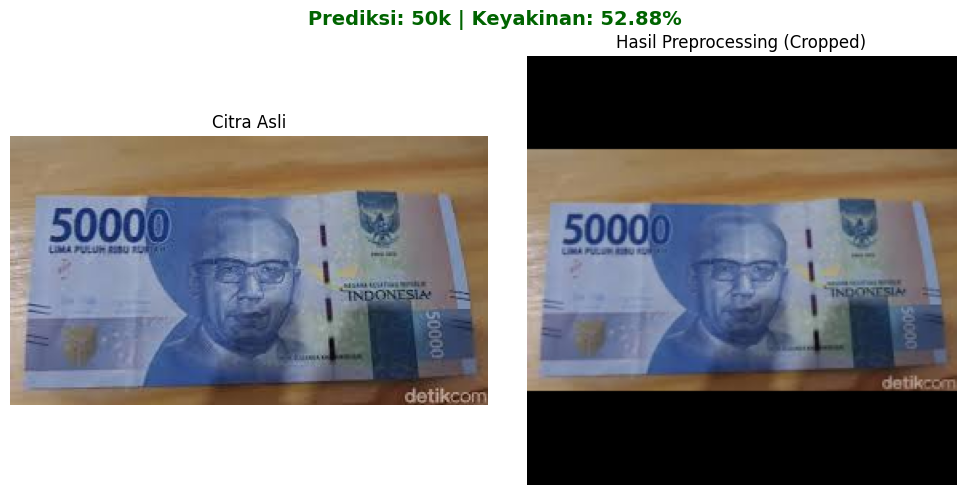

 HASIL PREDIKSI (MENGGUNAKAN CNN)
 Prediksi Akhir : Nominal 50k
 Nilai Keyakinan: 52.88%

 Rincian Confidence Score Tiap Kelas:
 - 10k        :   4.52%
 - 100k       :   9.19%
 - 20k        :   3.35%
 - 2k         :   6.08%
 - 50k        :  52.88%
 - 5k         :  23.98%


In [10]:
# Panggil fungsinya
predict_rupiah(IMAGE_PATH)